In [160]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import optuna

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

from torch.utils.data import (
    TensorDataset,
    DataLoader
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cuda


In [169]:
REPORT_DIR = Path("../../reports/forecasting_results")
MODEL_DIR = Path("../../models")
IMAGE_DIR = REPORT_DIR / "images"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
IMAGE_DIR.mkdir(parents=True, exist_ok=True)

# Load Historical Dataset

In [127]:
df = pd.read_parquet(
    "../../data/curated/environmental_master.parquet"
)

print(df.shape)

df.head()

(508116, 20)


,datetime,station_id,station_name,district,latitude,longitude,aqi,pm25,pm10,humidity,temperature,temperature_2m,relative_humidity_2m,dew_point_2m,precipitation,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,wind_gusts_10m
0,2022-01-01 21:00:00,WB005,"East Calcutta Girls College, Lake Town",Kolkata,22.601583,88.404556,123,66.79,109.32,71.50,18.09,15.6,87,13.4,0.0,1018.4,48,7.6,315,11.2
1,2022-01-01 21:00:00,WB009,Leather Complex,Kolkata,22.495300,88.509293,193,87.98,173.04,72.72,18.48,16.2,81,13.0,0.0,1018.6,18,7.4,331,12.6
2,2022-01-01 21:00:00,WB015,Sarsuna College,Kolkata,22.481270,88.284554,185,85.59,194.13,73.95,18.51,16.8,78,12.9,0.0,1018.7,57,7.4,317,13.3
3,2022-01-01 22:00:00,WB005,"East Calcutta Girls College, Lake Town",Kolkata,22.601583,88.404556,145,73.56,156.15,75.74,17.73,15.4,88,13.5,0.0,1018.3,100,7.4,321,11.2
4,2022-01-01 22:00:00,WB009,Leather Complex,Kolkata,22.495300,88.509293,231,99.37,168.51,75.08,18.05,15.6,85,13.1,0.0,1018.4,74,7.1,330,11.2


# Datetime Processing

In [128]:
df["datetime"] = pd.to_datetime(df["datetime"])

df = df.sort_values(
    ["station_id", "datetime"]
)

df.reset_index(drop=True, inplace=True)

print(df.shape)

(508116, 20)


# Temporal Features

In [129]:
df["hour"] = df["datetime"].dt.hour
df["month"] = df["datetime"].dt.month

df["hour_sin"] = np.sin(
    2*np.pi*df["hour"]/24
)

df["hour_cos"] = np.cos(
    2*np.pi*df["hour"]/24
)

df["month_sin"] = np.sin(
    2*np.pi*df["month"]/12
)

df["month_cos"] = np.cos(
    2*np.pi*df["month"]/12
)

# AQI Lag Features

In [130]:
lags = [1, 24, 168]

for lag in lags:

    df[f"aqi_lag_{lag}"] = (
        df.groupby("station_id")["aqi"]
        .shift(lag)
    )

# Forecast Horizon Dataset Builder

In [131]:
FEATURE_COLS = [

    "pm25",
    "pm10",

    "temperature_2m",
    "relative_humidity_2m",

    "surface_pressure",
    "wind_speed_10m",

    "precipitation",
    "cloud_cover",

    "hour_sin",
    "hour_cos",

    "month_sin",
    "month_cos",

    "aqi_lag_1",
    "aqi_lag_24",
    "aqi_lag_168"
]

print("Features:", len(FEATURE_COLS))

Features: 15


In [132]:
def prepare_horizon_data(
    dataframe,
    horizon
):

    temp = dataframe.copy()

    temp["target"] = (

        temp.groupby("station_id")["aqi"]

        .shift(-horizon)
    )

    temp = temp.dropna(
        subset=FEATURE_COLS + ["target"]
    )

    train = temp[
        temp["datetime"] <= "2024-12-31"
    ]

    validation = temp[
        (
            temp["datetime"] > "2024-12-31"
        )
        &
        (
            temp["datetime"] <= "2025-12-31"
        )
    ]

    test = temp[
        temp["datetime"] > "2025-12-31"
    ]

    return train, validation, test

# Cuda Check

In [133]:
import xgboost

print(
    "XGBoost Version:",
    xgboost.__version__
)

USE_CUDA = True

try:

    test_model = XGBRegressor(

        tree_method="hist",

        device="cuda"
    )

    print("CUDA Available")

except:

    USE_CUDA = False

    print("CUDA Not Available")

XGBoost Version: 2.0.3
CUDA Available


# Evaluation Function

In [134]:
# ==========================================
# Train + Evaluate
# ==========================================

def evaluate_horizon(
    train,
    test
):

    X_train = train[FEATURE_COLS]
    y_train = train["target"]

    X_test = test[FEATURE_COLS]
    y_test = test["target"]

    xgb_params = dict(

        n_estimators=454,

        max_depth=8,

        learning_rate=0.016366969566645424,

        subsample=0.7761434096072847,

        colsample_bytree=0.959474322773738,

        random_state=42
    )

    if USE_CUDA:

        xgb_params.update({

            "tree_method": "hist",

            "device": "cuda"
        })

    else:

        xgb_params.update({

            "tree_method": "hist"
        })

    models = {

        "Linear Regression":

        LinearRegression(),

        "Random Forest":

        RandomForestRegressor(

            n_estimators=300,

            max_depth=15,

            n_jobs=-1,

            random_state=42
        ),

        "XGBoost":

        XGBRegressor(
            **xgb_params
        )
    }

    results = []

    feature_importance = None

    for name, model in models.items():

        print(
            f"Training {name}"
        )

        model.fit(
            X_train,
            y_train
        )

        preds = model.predict(
            X_test
        )

        mae = mean_absolute_error(
            y_test,
            preds
        )

        rmse = np.sqrt(
            mean_squared_error(
                y_test,
                preds
            )
        )

        r2 = r2_score(
            y_test,
            preds
        )

        results.append([

            name,

            mae,

            rmse,

            r2
        ])

        if name == "XGBoost":

            feature_importance = pd.DataFrame({

                "feature":
                    FEATURE_COLS,

                "importance":
                    model.feature_importances_
            })

            feature_importance = (

                feature_importance

                .sort_values(
                    "importance",
                    ascending=False
                )
            )

    results_df = pd.DataFrame(

        results,

        columns=[
            "Model",
            "MAE",
            "RMSE",
            "R2"
        ]
    )

    return (

        results_df,

        feature_importance
    )


# Run Horizon Analysis


In [135]:
HORIZONS = [

    1,
    6,
    12,
    24
]

all_results = []

all_importance = {}

for horizon in HORIZONS:

    print(
        f"\n{'='*50}"
    )

    print(
        f"HORIZON: {horizon} HOURS"
    )

    train, val, test = (

        prepare_horizon_data(
            df,
            horizon
        )
    )

    results_df, importance_df = (

        evaluate_horizon(
            train,
            test
        )
    )

    results_df[
        "Forecast_Horizon"
    ] = horizon

    all_results.append(
        results_df
    )

    all_importance[
        horizon
    ] = importance_df

    display(results_df)


HORIZON: 1 HOURS
Training Linear Regression
Training Random Forest
Training XGBoost


,Model,MAE,RMSE,R2,Forecast_Horizon
0,Linear Regression,10.021494,16.674591,0.879331,1
1,Random Forest,7.706651,14.503272,0.908712,1
2,XGBoost,7.490258,14.043303,0.914410,1



HORIZON: 6 HOURS
Training Linear Regression
Training Random Forest
Training XGBoost


,Model,MAE,RMSE,R2,Forecast_Horizon
0,Linear Regression,22.884693,32.353142,0.546229,6
1,Random Forest,18.621234,28.368138,0.651129,6
2,XGBoost,18.024172,27.409746,0.674303,6



HORIZON: 12 HOURS
Training Linear Regression
Training Random Forest
Training XGBoost


,Model,MAE,RMSE,R2,Forecast_Horizon
0,Linear Regression,26.000536,35.404771,0.456972,12
1,Random Forest,21.980176,31.754631,0.563170,12
2,XGBoost,21.249227,30.918068,0.585883,12



HORIZON: 24 HOURS
Training Linear Regression
Training Random Forest
Training XGBoost


,Model,MAE,RMSE,R2,Forecast_Horizon
0,Linear Regression,19.618010,29.376951,0.621885,24
1,Random Forest,19.401346,29.588023,0.616432,24
2,XGBoost,19.044543,29.245592,0.625259,24


# Merge Results

In [136]:
horizon_model_results = pd.concat(
    all_results,
    ignore_index=True
)

horizon_model_results

,Model,MAE,RMSE,R2,Forecast_Horizon
0,Linear Regression,10.021494,16.674591,0.879331,1
1,Random Forest,7.706651,14.503272,0.908712,1
2,XGBoost,7.490258,14.043303,0.914410,1
3,Linear Regression,22.884693,32.353142,0.546229,6
4,Random Forest,18.621234,28.368138,0.651129,6
5,XGBoost,18.024172,27.409746,0.674303,6
6,Linear Regression,26.000536,35.404771,0.456972,12
7,Random Forest,21.980176,31.754631,0.563170,12
8,XGBoost,21.249227,30.918068,0.585883,12
9,Linear Regression,19.618010,29.376951,0.621885,24


# Save Results

In [137]:
horizon_model_results.to_csv(
    REPORT_DIR /
    "forecast_horizon_model_results.csv",
    index=False
)

print("Saved")

Saved


In [138]:
best_results = (

    horizon_model_results

    .sort_values(
        "R2",
        ascending=False
    )

    .groupby(
        "Forecast_Horizon"
    )

    .first()

    .reset_index()
)

best_results.to_csv(

    REPORT_DIR /

    "forecast_horizon_best_results.csv",

    index=False
)

best_results

,Forecast_Horizon,Model,MAE,RMSE,R2
0,1,XGBoost,7.490258,14.043303,0.914410
1,6,XGBoost,18.024172,27.409746,0.674303
2,12,XGBoost,21.249227,30.918068,0.585883
3,24,XGBoost,19.044543,29.245592,0.625259


In [139]:
for horizon, imp_df in all_importance.items():

    imp_df.to_csv(

        REPORT_DIR /

        f"feature_importance_{horizon}h.csv",

        index=False
    )

print("All Feature Importance Files Saved")

All Feature Importance Files Saved


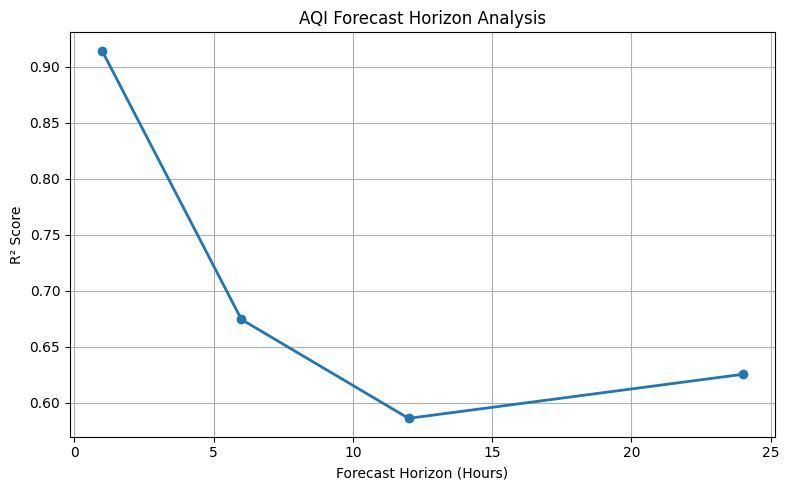

In [140]:
plt.figure(
    figsize=(8,5)
)

plt.plot(

    best_results[
        "Forecast_Horizon"
    ],

    best_results[
        "R2"
    ],

    marker="o",

    linewidth=2
)

plt.title(
    "AQI Forecast Horizon Analysis"
)

plt.xlabel(
    "Forecast Horizon (Hours)"
)

plt.ylabel(
    "R² Score"
)

plt.grid(True)

plt.tight_layout()

plt.savefig(

    IMAGE_DIR /

    "forecast_horizon_analysis.png",

    dpi=300
)

plt.show()

In [141]:
best_results

,Forecast_Horizon,Model,MAE,RMSE,R2
0,1,XGBoost,7.490258,14.043303,0.914410
1,6,XGBoost,18.024172,27.409746,0.674303
2,12,XGBoost,21.249227,30.918068,0.585883
3,24,XGBoost,19.044543,29.245592,0.625259
